In [1]:
import math
import pandas as pd
import numpy as np
import time
from collections import defaultdict
from gurobipy import Model, GRB, quicksum
import opendssdirect as dss 
dss.Text.Command(r'Redirect "C:\Users\lfang7\Project\Distribution network\OpenDSS Model\Master.dss"')
import random
seed = 42 
np.random.seed(seed)  
random.seed(seed) 

In [2]:
baseMVA = 10
basekV = 13.8
baseI = baseMVA * 1000 / (math.sqrt(3) * basekV)
I_max = 1000 * 1000 / baseI**2
Zb = basekV**2 / baseMVA
V_max = 1.05**2  
# relax the lower bound
V_min = 0.7**2  
T = range(8760) 

In [4]:
# Load Active Power from Excel files into NumPy arrays using pandas.
feederA_P = pd.read_excel('Calculated Nodal P&Q.xlsx', sheet_name='FeederA_P')  # Load active power data for Feeder A
feederB_P = pd.read_excel('Calculated Nodal P&Q.xlsx', sheet_name='FeederB_P')  # Load active power data for Feeder B
feederC_P = pd.read_excel('Calculated Nodal P&Q.xlsx', sheet_name='FeederC_P')  # Load active power data for Feeder C

# Load Reactive Power from Excel files into NumPy arrays using pandas.
feederA_Q = pd.read_excel('Calculated Nodal P&Q.xlsx', sheet_name='FeederA_Q')  # Load reactive power data for Feeder A
feederB_Q = pd.read_excel('Calculated Nodal P&Q.xlsx', sheet_name='FeederB_Q')  # Load reactive power data for Feeder B
feederC_Q = pd.read_excel('Calculated Nodal P&Q.xlsx', sheet_name='FeederC_Q')  # Load reactive power data for Feeder C

columnsA_P = feederA_P.columns.tolist()   
columnsB_P = feederB_P.columns.tolist()
columnsC_P = feederC_P.columns.tolist()
columnsA_Q = feederA_Q.columns.tolist()
columnsB_Q = feederB_Q.columns.tolist()
columnsC_Q = feederC_Q.columns.tolist()

# Rename the first column
columnsA_P[0] = 'Time'
columnsB_P[0] = 'Time'
columnsC_P[0] = 'Time'
columnsA_Q[0] = 'Time'
columnsB_Q[0] = 'Time'
columnsC_Q[0] = 'Time'

# Assign the updated column names back to the DataFrame
feederA_P.columns = columnsA_P
feederB_P.columns = columnsB_P
feederC_P.columns = columnsC_P
feederA_Q.columns = columnsA_Q
feederB_Q.columns = columnsB_Q
feederC_Q.columns = columnsC_Q

feederA_P['Time'] = pd.to_datetime(feederA_P['Time'])
feederB_P['Time'] = pd.to_datetime(feederB_P['Time'])
feederC_P['Time'] = pd.to_datetime(feederC_P['Time'])
feederA_Q['Time'] = pd.to_datetime(feederA_Q['Time'])
feederB_Q['Time'] = pd.to_datetime(feederB_Q['Time'])
feederC_Q['Time'] = pd.to_datetime(feederC_Q['Time'])

feederA_P.set_index(feederA_P.columns[0], inplace=True)
feederB_P.set_index(feederB_P.columns[0], inplace=True)
feederC_P.set_index(feederC_P.columns[0], inplace=True)
feederA_Q.set_index(feederA_Q.columns[0], inplace=True)
feederB_Q.set_index(feederB_Q.columns[0], inplace=True)
feederC_Q.set_index(feederC_Q.columns[0], inplace=True)

feeders_P = pd.concat([feederA_P, feederB_P, feederC_P], axis=1)
feeders_Q = pd.concat([feederA_Q, feederB_Q, feederC_Q], axis=1)

In [4]:
feeders_P

,Bus 1001,Bus 1002,Bus 1003,Bus 1004,Bus 1005,Bus 1006,Bus 1007,Bus 1008,Bus 1009,Bus 1010,...,Bus 3153,Bus 3154,Bus 3155,Bus 3156,Bus 3157,Bus 3158,Bus 3159,Bus 3160,Bus 3161,Bus 3162
Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 01:00:00.000,0,0,15.290,6.892,4.916,5.04,4.163,14.0960,17.081,7.136,...,5.9760,4.836,1.47700,0,9.740,6.517,9.776,4.252,2.744,3.750
2017-01-01 02:00:00.000,0,0,14.901,6.672,5.335,4.76,3.070,14.9370,12.786,7.078,...,7.1270,6.638,1.48800,0,7.721,6.858,9.565,4.154,3.468,3.710
2017-01-01 03:00:00.005,0,0,15.772,7.013,4.563,5.04,3.507,14.7890,10.209,5.991,...,6.4710,7.292,1.69500,0,7.194,6.805,9.146,4.429,1.677,3.762
2017-01-01 04:00:00.010,0,0,15.757,6.452,4.782,4.80,3.143,14.7610,10.040,7.030,...,5.4740,5.162,1.58500,0,6.533,5.952,9.319,4.192,1.614,3.993
2017-01-01 05:00:00.015,0,0,15.292,6.356,4.482,5.00,3.147,15.1560,10.147,6.043,...,5.5750,5.443,1.59200,0,6.816,5.790,8.417,2.948,2.208,3.183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 20:00:43.770,0,0,17.613,6.635,9.339,7.92,9.038,12.4775,28.646,17.349,...,23.6007,3.980,4.59300,0,13.109,11.565,24.687,4.606,4.080,4.495
2017-12-31 21:00:43.775,0,0,17.181,6.455,5.926,7.68,10.707,11.8412,30.693,14.129,...,23.6007,2.319,4.63400,0,15.567,14.881,22.210,4.836,3.717,5.231
2017-12-31 22:00:43.780,0,0,16.932,6.196,5.675,7.40,10.144,12.3205,28.453,15.130,...,24.7513,3.468,3.58850,0,14.046,16.346,22.785,3.339,3.139,5.525


In [5]:
# Sum of every bus
sum_bus_feeders_P = np.sum(feeders_P, axis=0)

# Total sum of all buses
sum_feeders_P = np.sum(sum_bus_feeders_P)

# Average power consumption per household per year
avg_power_year = sum_feeders_P / 1120

# Average power consumption per household per hour
avg_power_hour = avg_power_year / 8760

print(f'Total Active Power in All Feeders: {sum_feeders_P:.2f} kW')
print(f'Average Active Power consumption for 1120 households (year) : {avg_power_year:.4f} kW')
print(f'Average Active Power consumption for 1120 households (hour): {avg_power_hour:.4f} kW')

Total Active Power in All Feeders: 13123541.50 kW
Average Active Power consumption for 1120 households (year) : 11717.4478 kW
Average Active Power consumption for 1120 households (hour): 1.3376 kW


In [6]:
# Increase the general load value
nonzero_buses_P = [bus for bus in feeders_P.columns if not feeders_P[bus].eq(0).all()]
feeders_P[nonzero_buses_P] = feeders_P[nonzero_buses_P] *1.0

nonzero_buses_Q = [bus for bus in feeders_Q.columns if not feeders_Q[bus].eq(0).all()]
feeders_Q[nonzero_buses_Q] = feeders_Q[nonzero_buses_Q] *1.0

print("All Load value has increased")

All Load value has increased


In [7]:
Loads_act = dss.utils.loads_to_dataframe()
Loads_act

,Name,Idx,Phases,Class,Model,NumCust,IsDelta,Rneut,Xneut,PF,...,kV,kW,kVABase,kvar,kWh,kWhDays,AllocationFactor,XfkVA,puSeriesRL,Sensor
load_1003,load_1003,1,3,1,1,1,False,-1.0,0.0,0.97,...,0.208,15.29,15.762887,3.832035,0.0,30.0,0.5,0.0,50.0,
load_1004,load_1004,2,3,1,1,1,False,-1.0,0.0,0.9,...,0.208,6.892,7.657778,3.337948,0.0,30.0,0.5,0.0,50.0,
load_1005,load_1005,3,3,1,1,1,False,-1.0,0.0,0.93,...,0.208,4.916,5.286022,1.942928,0.0,30.0,0.5,0.0,50.0,
load_1006,load_1006,4,1,1,1,1,True,-1.0,0.0,0.91,...,0.208,5.04,5.538462,2.296292,0.0,30.0,0.5,0.0,50.0,
load_1007,load_1007,5,1,1,1,1,True,-1.0,0.0,0.9,...,0.208,4.163,4.625556,2.016233,0.0,30.0,0.5,0.0,50.0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
load_3158,load_3158,190,2,1,1,1,False,-1.0,0.0,0.97,...,0.208,6.517,6.718557,1.633314,0.0,30.0,0.5,0.0,50.0,
load_3159,load_3159,191,2,1,1,1,False,-1.0,0.0,0.91,...,0.208,9.776,10.742857,4.454077,0.0,30.0,0.5,0.0,50.0,
load_3160,load_3160,192,2,1,1,1,False,-1.0,0.0,0.95,...,0.208,4.252,4.475789,1.397565,0.0,30.0,0.5,0.0,50.0,
load_3161,load_3161,193,2,1,1,1,False,-1.0,0.0,0.99,...,0.208,2.744,2.771717,0.390999,0.0,30.0,0.5,0.0,50.0,


In [8]:
df_users = pd.read_excel(r'C:\Users\lfang7\Project\Distribution network\Add EV dataset\users number_1120.xlsx')
df_users['Load Name_lower'] = df_users['Load Name'].str.lower()

In [9]:
df_users

,Load Name,Number of customers,EVs 0%,EVs 20%,EVs 40%,EVs 60%,EVs 80%,EVs 100%,Load Name_lower
0,Load_1003,17,0,6,8,13,10,17,load_1003
1,Load_1004,8,0,4,3,8,6,8,load_1004
2,Load_1005,8,0,3,6,2,8,8,load_1005
3,Load_1006,5,0,2,2,3,4,5,load_1006
4,Load_1007,3,0,1,2,3,3,3,load_1007
...,...,...,...,...,...,...,...,...,...
189,Load_3158,6,0,0,2,6,5,6,load_3158
190,Load_3159,8,0,1,2,5,2,8,load_3159
191,Load_3160,3,0,0,1,3,3,3,load_3160
192,Load_3161,2,0,0,2,2,2,2,load_3161


In [10]:
# Calculate the sum of each row
row_sums = feeders_P.sum(axis=1)

# Find the index of the row with the highest sum
max_row_index = row_sums.idxmax()

# Display the row with the highest sum
max_row_P = feeders_P.loc[max_row_index]

print(f"Row with the highest sum is at index: {max_row_index}")

Row with the highest sum is at index: 2017-07-12 13:00:23.095000


In [11]:
max_row_P_df = max_row_P.to_frame().T
max_row_P_df

,Bus 1001,Bus 1002,Bus 1003,Bus 1004,Bus 1005,Bus 1006,Bus 1007,Bus 1008,Bus 1009,Bus 1010,...,Bus 3153,Bus 3154,Bus 3155,Bus 3156,Bus 3157,Bus 3158,Bus 3159,Bus 3160,Bus 3161,Bus 3162
2017-07-12 13:00:23.095,0.0,0.0,66.155,29.835,47.733,19.36,3.915,10.4869,25.773,12.666,...,14.9431,8.13,9.514,0.0,17.722,15.606,23.042,4.883,7.097,8.494


In [12]:
# Display the row with the highest sum
max_row_Q = feeders_Q.loc[max_row_index]

# Convert the Series (max_row) to a DataFrame and transpose it
max_row_Q_df = max_row_Q.to_frame().T
max_row_Q_df

,Bus 1001,Bus 1002,Bus 1003,Bus 1004,Bus 1005,Bus 1006,Bus 1007,Bus 1008,Bus 1009,Bus 1010,...,Bus 3153,Bus 3154,Bus 3155,Bus 3156,Bus 3157,Bus 3158,Bus 3159,Bus 3160,Bus 3161,Bus 3162
2017-07-12 13:00:23.095,0.0,0.0,9.426577,8.701875,20.334173,2.758651,1.783727,2.628265,7.517125,4.163113,...,5.905891,3.937539,4.052947,0.0,5.168917,6.648128,10.498245,2.080149,1.011268,2.128797


In [13]:
charging_power = 5  # 5 10 15 EV charger rating capacity
ev_rate = [0, 20, 40, 60, 80, 100] # penetration rate

base_P_series = max_row_P_df.iloc[0] 

result_indices = df_users['Load Name']
max_row_P_ev_df = pd.DataFrame(index=result_indices, columns=[f'Updated P {r}%' for r in ev_rate])
max_row_Q_ev_df = pd.DataFrame(index=result_indices, columns=[f'Updated Q {r}%' for r in ev_rate])

for adoption_rate in ev_rate:
    ev_col_name = f'EVs {adoption_rate}%'
    result_col_name = f'Updated P {adoption_rate}%'
    result_col_name_Q = f'Updated Q {adoption_rate}%'
    
    for i, row in df_users.iterrows():
        load_name = row['Load Name'] 
        bus_id = load_name.split('_')[1] 
        bus_col_name = f"Bus {bus_id}"  

        if bus_col_name in base_P_series.index:
            base_P = base_P_series[bus_col_name]
            ev_count = row[ev_col_name]
            additional_P = ev_count * charging_power
            updated_P = base_P + additional_P
            pf = np.random.uniform(0.9, 0.95)
            
            if updated_P > 0:
                # Q = P * tan(arccos(pf))
                updated_Q = updated_P * np.tan(np.arccos(pf))
            else:
                updated_Q = 0

            max_row_P_ev_df.at[load_name, result_col_name] = updated_P
            max_row_Q_ev_df.at[load_name, result_col_name_Q] = updated_Q
            
        else:
            max_row_P_ev_df.at[load_name, result_col_name] = 0
            max_row_Q_ev_df.at[load_name, result_col_name_Q] = 0

print("Updated Active Power (P) with EVs:")
display(max_row_P_ev_df.head())

print("\nUpdated Reactive Power (Q) with EVs:")
display(max_row_Q_ev_df.head())

Updated Active Power (P) with EVs:


,Updated P 0%,Updated P 20%,Updated P 40%,Updated P 60%,Updated P 80%,Updated P 100%
Load Name,,,,,,
Load_1003,66.155,96.155,106.155,131.155,116.155,151.155
Load_1004,29.835,49.835,44.835,69.835,59.835,69.835
Load_1005,47.733,62.733,77.733,57.733,87.733,87.733
Load_1006,19.36,29.36,29.36,34.36,39.36,44.36
Load_1007,3.915,8.915,13.915,18.915,18.915,18.915



Updated Reactive Power (Q) with EVs:


,Updated Q 0%,Updated Q 20%,Updated Q 40%,Updated Q 60%,Updated Q 80%,Updated Q 100%
Load Name,,,,,,
Load_1003,28.435176,41.840513,39.392399,54.024011,52.425843,58.214833
Load_1004,10.064798,21.609329,16.222055,30.49461,22.480192,23.727259
Load_1005,17.857897,23.531272,25.680318,22.513035,32.993087,32.814468
Load_1006,7.655646,10.176194,12.451402,15.453362,15.300076,20.114384
Load_1007,1.808718,3.105202,5.9863,8.956743,7.192949,9.077258


In [14]:
P_series = max_row_P / (baseMVA * 1000)
Q_series = max_row_Q / (baseMVA * 1000)

T = [max_row_index]

P_load_dict = {}
Q_load_dict = {}

for col_name, value in P_series.items():

    if "Bus" in str(col_name):
        bus_id = int(str(col_name).replace("Bus", "").strip())

        P_load_dict[(bus_id, max_row_index)] = value

        Q_value = Q_series[col_name]
        Q_load_dict[(bus_id, max_row_index)] = Q_value

已生成 P_load_dict，包含 239 个负荷点，时刻为: 2017-07-12 13:00:23.095000


In [15]:
P_load_dict

{(1001, Timestamp('2017-07-12 13:00:23.095000')): 0.0,
 (1002, Timestamp('2017-07-12 13:00:23.095000')): 0.0,
 (1003, Timestamp('2017-07-12 13:00:23.095000')): 0.0066155,
 (1004, Timestamp('2017-07-12 13:00:23.095000')): 0.0029835,
 (1005, Timestamp('2017-07-12 13:00:23.095000')): 0.004773299999999999,
 (1006, Timestamp('2017-07-12 13:00:23.095000')): 0.001936,
 (1007, Timestamp('2017-07-12 13:00:23.095000')): 0.00039150000000000003,
 (1008, Timestamp('2017-07-12 13:00:23.095000')): 0.0010486900000000001,
 (1009, Timestamp('2017-07-12 13:00:23.095000')): 0.0025773,
 (1010, Timestamp('2017-07-12 13:00:23.095000')): 0.0012666,
 (1011, Timestamp('2017-07-12 13:00:23.095000')): 0.0008669000000000001,
 (1012, Timestamp('2017-07-12 13:00:23.095000')): 0.000562,
 (1013, Timestamp('2017-07-12 13:00:23.095000')): 0.0008236000000000001,
 (1014, Timestamp('2017-07-12 13:00:23.095000')): 0.00024430000000000003,
 (1015, Timestamp('2017-07-12 13:00:23.095000')): 0.00032189999999999996,
 (1016, Times

In [16]:
len(P_load_dict)

239

In [17]:
# random substation bus voltage level
voltage_df = pd.read_excel(r"C:\Users\lfang7\Project\Distribution network\Add EV code\bus1_voltage_mean.xlsx")
voltage_df["TimeStep"] = pd.to_datetime(voltage_df["TimeStep"])
voltage_df_filtered = voltage_df[voltage_df["TimeStep"].isin(T)].copy()
bus1_voltage_mean = dict(zip(voltage_df_filtered["TimeStep"], voltage_df_filtered["Bus1 Voltage Mean (p.u.)"]))
print(voltage_df_filtered["TimeStep"].head())

Bus1 电压字典已生成，包含 1 个时间点。
4620   2017-07-12 13:00:23.095
Name: TimeStep, dtype: datetime64[ns]


In [18]:
# without transformer impedance all 3-phase lines
gen = [(1, 0, 0, 300, -300, 1.02, 10, 1, 300, 0)]

branch = [
    (1, 1, 1001, 0.0001, 0.0001, 340),
    (2, 1, 2001, 0.0001, 0.0001, 340),
    (3, 1, 3001, 0.0001, 0.0001, 340),
    (4, 1001, 1002, 0.3369854539772726, 0.22045428125, 326),
    (5, 1002, 1003, 0.08049361363636363, 0.03148085227272727, 228),
    (6, 1002, 1004, 0.05377083333333333, 0.09379095416666668, 340),
    (7, 1004, 1005, 0.03320643939393939, 0.05792105946969697, 340),
    (8, 1005, 1006, 0.08841003787878787, 0.1542111456439394, 340),
    (9, 1006, 1007, 0.1685606060606061, 0.2940155303030303, 340),
    (10, 1006, 1008, 0.03826325757575758, 0.06674152537878789, 340),
    (11, 1008, 1009, 0.09119128787878786, 0.1590624018939394, 340),
    (12, 1009, 1010, 0.01424337121212121, 0.02484431231060606, 340),
    (13, 1009, 1011, 0.01298284090909091, 0.005077556818181819, 228),
    (14, 1011, 1012, 0.01298284090909091, 0.005077556818181819, 228),
    (15, 1012, 1013, 0.06621248863636364, 0.02589553977272728, 228),
    (16, 1013, 1014, 0.04500718181818181, 0.01760219696969697, 228),
    (17, 1014, 1015, 0.02726396590909091, 0.01066286931818182, 228),
    (18, 1013, 1016, 0.1012661590909091, 0.03960494318181819, 228),
    (19, 1016, 1017, 0.01536302840909091, 0.006008442234848485, 228),
    (20, 2001, 2002, 0.1576460431818182, 0.1031312916666667, 326),
    (21, 2002, 2003, 0.1079630681818182, 0.1883169471590909, 340),
    (22, 2003, 2004, 0.06725568181818181, 0.1173121965909091, 340),
    (23, 2004, 2005, 0.02671685606060606, 0.04660146155303031, 340),
    (24, 2005, 2006, 0.01222064393939394, 0.0213161259469697, 340),
    (25, 2006, 2007, 0.04439478882575758, 0.03341786079545454, 242),
    (26, 2007, 2008, 0.02704758522727273, 0.01057824337121212, 228),
    (27, 2007, 2009, 0.02917371837121212, 0.02196030852272727, 242),
    (28, 2006, 2010, 0.01432765151515152, 0.02499132007575758, 340),
    (29, 2010, 2011, 0.02317708333333333, 0.04042713541666667, 340),
    (30, 2011, 2012, 0.04239299242424242, 0.07394490587121211, 340),
    (31, 2012, 2013, 0.0001, 0.0001, 340),
    (32, 2013, 2014, 0.02258712121212121, 0.03939808106060606, 340),
    (33, 2014, 2015, 0.02596568181818182, 0.01015511363636364, 228),
    (34, 2014, 2016, 0.02166003787878788, 0.0377809956439394, 340),
    (35, 2016, 2017, 0.03765023863636363, 0.01472491477272727, 228),
    (36, 2017, 2018, 0.09672216477272727, 0.03782779829545455, 228),
    (37, 2013, 2019, 0.003792613636363636, 0.006615349431818181, 340),
    (38, 2019, 2020, 0.1389163977272727, 0.05432985795454547, 228),
    (39, 2019, 2021, 0.003624053030303031, 0.006321333901515153, 340),
    (40, 2021, 2022, 0.04435803977272727, 0.01734831912878788, 228),
    (41, 2022, 2023, 0.03245710227272727, 0.01269389204545454, 228),
    (42, 2023, 2024, 0.08828331818181819, 0.03452738636363636, 228),
    (43, 2024, 2025, 0.07162200568181817, 0.0280111884469697, 228),
    (44, 2021, 2026, 0.0001, 0.0001, 340),
    (45, 2026, 2027, 0.03109943181818182, 0.0542458653409091, 340),
    (46, 2027, 2028, 0.06166849431818182, 0.02411839488636364, 228),
    (47, 2028, 2029, 0.02834586931818182, 0.0110859990530303, 228),
    (48, 2029, 2030, 0.0357028125, 0.01396328125, 228),
    (49, 2030, 2031, 0.05301326704545455, 0.02073335700757576, 228),
    (50, 2027, 2032, 0.01255776515151515, 0.02190415700757576, 340),
    (51, 2032, 2033, 0.02435700757575757, 0.04248524412878787, 340),
    (52, 2033, 2034, 0.03352259564393939, 0.02523389488636363, 242),
    (53, 2033, 2035, 0.01348484848484848, 0.02352124242424242, 340),
    (54, 2035, 2036, 0.01348484848484848, 0.02352124242424242, 340),
    (55, 2036, 2037, 0.006742424242424242, 0.01176062121212121, 340),
    (56, 2037, 2038, 0.01618181818181818, 0.02822549090909091, 340),
    (57, 2038, 2039, 0.06742424242424241, 0.1176062121212121, 340),
    (58, 2039, 2040, 0.02604261363636364, 0.04542539943181818, 340),
    (59, 2040, 2041, 0.03227935606060606, 0.05630397405303032, 340),
    (60, 2039, 2042, 0.007573323863636364, 0.002961908143939395, 228),
    (61, 2042, 2043, 0.03418814772727272, 0.01337089962121212, 228),
    (62, 2043, 2044, 0.0740021931818182, 0.02894207386363636, 228),
    (63, 2044, 2045, 0.06989096022727273, 0.02733418087121212, 228),
    (64, 2045, 2046, 0.071405625, 0.0279265625, 228),
    (65, 2045, 2047, 0.04089594886363636, 0.01599430397727273, 228),
    (66, 2047, 2048, 0.05604259659090909, 0.02191812026515151, 228),
    (67, 2044, 2049, 0.02812948863636364, 0.01100137310606061, 228),
    (68, 2049, 2050, 0.02683120454545455, 0.01049361742424243, 228),
    (69, 2050, 2051, 0.03007691477272727, 0.01176300662878788, 228),
    (70, 2051, 2052, 0.02899501136363637, 0.01133987689393939, 228),
    (71, 2044, 2053, 0.1004006363636364, 0.0392664393939394, 228),
    (72, 2053, 2054, 0.03007691477272727, 0.01176300662878788, 228),
    (73, 2054, 2055, 0.03375538636363637, 0.01320164772727273, 228),
    (74, 2055, 2056, 0.04414165909090909, 0.01726369318181818, 228),
    (75, 2053, 2057, 0.1646656988636364, 0.0644003456439394, 228),
    (76, 2057, 2058, 0.0880669375, 0.03444276041666668, 228),
    (77, 2057, 2059, 0.1482207670454546, 0.05796877367424243, 228),
    (78, 2059, 2060, 0.06577972727272727, 0.02572628787878788, 228),
    (79, 3001, 3003, 0.2620240789772727, 0.17141490625, 326),
    (80, 3003, 3002, 0.01839235795454545, 0.007193205492424243, 228),
    (81, 3003, 3004, 0.01752683522727273, 0.006854701704545455, 228),
    (82, 3003, 3005, 0.2268149482954546, 0.1483812604166667, 326),
    (83, 3005, 3006, 0.02621117424242424, 0.0457194149621212, 340),
    (84, 3006, 3007, 0.03118371212121212, 0.05439287310606061, 340),
    (85, 3005, 3008, 0.01146212121212121, 0.01999305606060606, 340),
    (86, 3008, 3009, 0.02917371837121212, 0.02196030852272727, 242),
    (87, 3009, 3010, 0.0628775172348485, 0.04733060284090908, 242),
    (88, 3010, 3011, 0.04801885321969697, 0.03614584943181817, 242),
    (89, 3011, 3012, 0.05653540454545455, 0.04255662272727273, 242),
    (90, 3008, 3013, 0.03080454734848485, 0.0231879034090909, 242),
    (91, 3013, 3014, 0.05345494981060606, 0.04023783238636364, 242),
    (92, 3008, 3015, 0.02713825757575758, 0.04733650037878788, 340),
    (93, 3015, 3016, 0.03805267613636364, 0.02864388068181818, 242),
    (94, 3016, 3017, 0.04693163390151515, 0.03532745284090909, 242),
    (95, 3015, 3018, 0.03279778276515151, 0.02468829715909091, 242),
    (96, 3018, 3019, 0.05091810473484849, 0.03832824034090909, 242),
    (97, 3019, 3020, 0.0556293884469697, 0.04187462556818182, 242),
    (98, 3020, 3021, 0.05490457556818182, 0.04132902784090908, 242),
    (99, 3015, 3022, 0.02435700757575757, 0.04248524412878787, 340),
    (100, 3022, 3023, 0.03279778276515151, 0.02468829715909091, 242),
    (101, 3023, 3024, 0.05798503030303031, 0.04364781818181819, 242),
    (102, 3024, 3025, 0.05997826571969697, 0.04514821193181819, 242),
    (103, 3022, 3026, 0.02971732803030303, 0.02236950681818182, 242),
    (104, 3026, 3027, 0.06668278484848486, 0.05019499090909092, 242),
    (105, 3027, 3028, 0.0436699759469697, 0.03287226306818182, 242),
    (106, 3028, 3029, 0.05744142064393939, 0.04323861988636363, 242),
    (107, 3022, 3030, 0.02562121212121212, 0.0446903606060606, 340),
    (108, 3030, 3035, 0.008680871212121213, 0.01514179981060606, 340),
    (109, 3035, 3036, 0.02283996212121212, 0.0398391043560606, 340),
    (110, 3036, 3037, 0.01146212121212121, 0.01999305606060606, 340),
    (111, 3037, 3038, 0.02123863636363637, 0.03704595681818182, 340),
    (112, 3038, 3039, 0.01980587121212122, 0.03454682481060606, 340),
    (113, 3039, 3053, 0.0221657196969697, 0.03866304223484849, 340),
    (114, 3053, 3054, 0.06058659090909091, 0.02369526515151516, 228),
    (115, 3053, 3055, 0.2888682102272727, 0.1129756392045455, 228),
    (116, 3055, 3056, 0.02769672727272728, 0.01083212121212121, 228),
    (117, 3056, 3057, 0.03851576136363637, 0.01506341856060606, 228),
    (118, 3057, 3058, 0.03851576136363637, 0.01506341856060606, 228),
    (119, 3058, 3059, 0.05928830681818181, 0.02318750946969697, 228),
    (120, 3059, 3060, 0.0166613125, 0.006516197916666668, 228),
    (121, 3060, 3061, 0.03981404545454546, 0.01557117424242424, 228),
    (122, 3055, 3062, 0.09585664204545455, 0.03748929450757577, 228),
    (123, 3062, 3063, 0.042843375, 0.0167559375, 228),
    (124, 3063, 3064, 0.03397176704545454, 0.01328627367424243, 228),
    (125, 3064, 3065, 0.04435803977272727, 0.01734831912878788, 228),
    (126, 3065, 3066, 0.02661482386363637, 0.01040899147727273, 228),
    (127, 3066, 3067, 0.05928830681818181, 0.02318750946969697, 228),
    (128, 3030, 3040, 0.02798106060606061, 0.04880657803030303, 340),
    (129, 3040, 3044, 0.02609326363636364, 0.01964151818181818, 242),
    (130, 3044, 3045, 0.07121286534090909, 0.05360497670454545, 242),
    (131, 3040, 3041, 0.02192558958333333, 0.01650433125, 242),
    (132, 3041, 3042, 0.05943465606060606, 0.04473901363636364, 242),
    (133, 3042, 3043, 0.07574294583333334, 0.05701496249999999, 242),
    (134, 3040, 3046, 0.0277282196969697, 0.04836555473484849, 340),
    (135, 3046, 3047, 0.01845738636363637, 0.03219470056818182, 340),
    (136, 3046, 3048, 0.01095643939393939, 0.01911100946969697, 340),
    (137, 3048, 3049, 0.01904734848484848, 0.03322375492424243, 340),
    (138, 3049, 3050, 0.01407481060606061, 0.02455029678030303, 340),
    (139, 3050, 3051, 0.03034090909090909, 0.05292279545454545, 340),
    (140, 3051, 3052, 0.02460984848484848, 0.04292626742424244, 340),
    (141, 3030, 3031, 0.02048011363636364, 0.03572288693181819, 340),
    (142, 3031, 3032, 0.02115435606060606, 0.0368989490530303, 340),
    (143, 3032, 3033, 0.03270075757575758, 0.05703901287878788, 340),
    (144, 3033, 3034, 0.02166003787878788, 0.0377809956439394, 340),
    (145, 3034, 3068, 0.0138219696969697, 0.02410927348484848, 340),
    (146, 3068, 3069, 0.0277282196969697, 0.04836555473484849, 340),
    (147, 3069, 3070, 0.02315273295454545, 0.009054976325757575, 228),
    (148, 3070, 3071, 0.03050967613636364, 0.01193225852272727, 228),
    (149, 3071, 3072, 0.01947426136363636, 0.007616335227272728, 228),
    (150, 3069, 3073, 0.001685606060606061, 0.002940155303030303, 340),
    (151, 3073, 3074, 0.02865530303030303, 0.04998264015151516, 340),
    (152, 3068, 3075, 0.01584469696969697, 0.02763745984848485, 340),
    (153, 3075, 3076, 0.0001, 0.0001, 340),
    (154, 3076, 3077, 0.07391382575757577, 0.1289258100378788, 340),
    (155, 3077, 3078, 0.006742424242424242, 0.01176062121212121, 340),
    (156, 3076, 3079, 0.01609753787878788, 0.02807848314393939, 340),
    (157, 3079, 3080, 0.05090530303030303, 0.08879269015151514, 340),
    (158, 3080, 3081, 0.01643465909090909, 0.02866651420454545, 340),
    (159, 3080, 3082, 0.04551136363636363, 0.07938419318181819, 340),
    (160, 3082, 3083, 0.02704758522727273, 0.01057824337121212, 228),
    (161, 3083, 3084, 0.04241061363636364, 0.01658668560606061, 228),
    (162, 3084, 3085, 0.1114360511363636, 0.04358236268939394, 228),
    (163, 3085, 3086, 0.07313667045454544, 0.02860357007575758, 228),
    (164, 3086, 3087, 0.05171498295454545, 0.02022560132575758, 228),
    (165, 3087, 3088, 0.09087988636363636, 0.03554289772727272, 228),
    (166, 3088, 3089, 0.02423463636363636, 0.009478106060606062, 228),
    (167, 3089, 3090, 0.1222550852272727, 0.04781366003787879, 228),
    (168, 3090, 3091, 0.04803651136363636, 0.01878696022727273, 228),
    (169, 3082, 3092, 0.04003042613636364, 0.01565580018939394, 228),
    (170, 3092, 3093, 0.04976755681818182, 0.0194639678030303, 228),
    (171, 3093, 3094, 0.02704758522727273, 0.01057824337121212, 228),
    (172, 3094, 3095, 0.01406474431818182, 0.005500686553030303, 228),
    (173, 3095, 3096, 0.06404868181818181, 0.02504928030303031, 228),
    (174, 3096, 3097, 0.02531653977272727, 0.009901235795454547, 228),
    (175, 3092, 3098, 0.06145211363636364, 0.02403376893939394, 228),
    (176, 3098, 3099, 0.07962809090909091, 0.03114234848484849, 228),
    (177, 3092, 3100, 0.01969064204545454, 0.007700961174242424, 228),
    (178, 3100, 3101, 0.03397176704545454, 0.01328627367424243, 228),
    (179, 3101, 3102, 0.0486856534090909, 0.01904083806818182, 228),
    (180, 3102, 3103, 0.02899501136363637, 0.01133987689393939, 228),
    (181, 3100, 3104, 0.04825289204545455, 0.01887158617424242, 228),
    (182, 3104, 3105, 0.02596568181818182, 0.01015511363636364, 228),
    (183, 3105, 3106, 0.0391649034090909, 0.01531729640151515, 228),
    (184, 3082, 3107, 0.1659372255681818, 0.10855534375, 326),
    (185, 3107, 3108, 0.1008333977272727, 0.03943569128787879, 228),
    (186, 3108, 3109, 0.02942777272727273, 0.01150912878787879, 228),
    (187, 3109, 3110, 0.03288986363636363, 0.01286314393939394, 228),
    (188, 3110, 3111, 0.05972106818181818, 0.02335676136363636, 228),
    (189, 3111, 3112, 0.07097286363636364, 0.02775731060606061, 228),
    (190, 3107, 3113, 0.05301326704545455, 0.02073335700757576, 228),
    (191, 3113, 3114, 0.0322407215909091, 0.01260926609848485, 228),
    (192, 3114, 3115, 0.07162200568181817, 0.0280111884469697, 228),
    (193, 3113, 3116, 0.09866959090909092, 0.03858943181818182, 228),
    (194, 3116, 3117, 0.02423463636363636, 0.009478106060606062, 228),
    (195, 3107, 3118, 0.2574809653409091, 0.1684428229166667, 326),
    (196, 3118, 3119, 0.1004006363636364, 0.0392664393939394, 228),
    (197, 3119, 3120, 0.07573323863636364, 0.02961908143939394, 228),
    (198, 3120, 3121, 0.04457442045454546, 0.01743294507575758, 228),
    (199, 3121, 3122, 0.03829938068181818, 0.01497879261363636, 228),
    (200, 3119, 3123, 0.01969064204545454, 0.007700961174242424, 228),
    (201, 3123, 3124, 0.01449750568181818, 0.005669938446969697, 228),
    (202, 3124, 3125, 0.03267348295454545, 0.01277851799242424, 228),
    (203, 3125, 3126, 0.07421857386363635, 0.02902669981060606, 228),
    (204, 3126, 3127, 0.05063307954545455, 0.01980247159090909, 228),
    (205, 3127, 3128, 0.05149860227272726, 0.02014097537878788, 228),
    (206, 3128, 3129, 0.05258050568181818, 0.02056410511363636, 228),
    (207, 3129, 3130, 0.04976755681818182, 0.0194639678030303, 228),
    (208, 3130, 3131, 0.04197785227272727, 0.01641743371212121, 228),
    (209, 3118, 3132, 0.1084067215909091, 0.04239759943181818, 228),
    (210, 3132, 3133, 0.03137519886363636, 0.01227076231060606, 228),
    (211, 3133, 3134, 0.0608029715909091, 0.02377989109848485, 228),
    (212, 3134, 3135, 0.05193136363636364, 0.02031022727272727, 228),
    (213, 3135, 3136, 0.07941171022727272, 0.03105772253787879, 228),
    (214, 3133, 3137, 0.05452793181818182, 0.02132573863636364, 228),
    (215, 3137, 3138, 0.07594961931818181, 0.02970370738636364, 228),
    (216, 3138, 3139, 0.06253401704545454, 0.02445689867424243, 228),
    (217, 3107, 3140, 0.05517707386363636, 0.02157961647727272, 228),
    (218, 3140, 3141, 0.02899501136363637, 0.01133987689393939, 228),
    (219, 3141, 3142, 0.04176147159090909, 0.01633280776515152, 228),
    (220, 3142, 3143, 0.04370889772727272, 0.01709444128787879, 228),
    (221, 3140, 3148, 0.03180796022727272, 0.01244001420454545, 228),
    (222, 3148, 3149, 0.0547443125, 0.02141036458333334, 228),
    (223, 3149, 3150, 0.03007691477272727, 0.01176300662878788, 228),
    (224, 3150, 3151, 0.03375538636363637, 0.01320164772727273, 228),
    (225, 3151, 3152, 0.05625897727272727, 0.02200274621212121, 228),
    (226, 3152, 3153, 0.03007691477272727, 0.01176300662878788, 228),
    (227, 3153, 3154, 0.02574930113636363, 0.01007048768939394, 228),
    (228, 3154, 3155, 0.1092722443181818, 0.04273610321969697, 228),
    (229, 3140, 3156, 0.06902543750000001, 0.02699567708333333, 228),
    (230, 3156, 3144, 0.02639844318181818, 0.01032436553030303, 228),
    (231, 3144, 3145, 0.03851576136363637, 0.01506341856060606, 228),
    (232, 3145, 3146, 0.03851576136363637, 0.01506341856060606, 228),
    (233, 3146, 3147, 0.03851576136363637, 0.01506341856060606, 228),
    (234, 3156, 3157, 0.03310624431818182, 0.01294776988636364, 228),
    (235, 3157, 3158, 0.06383230113636364, 0.02496465435606061, 228),
    (236, 3158, 3159, 0.05560983522727274, 0.02174886837121212, 228),
    (237, 3159, 3160, 0.05258050568181818, 0.02056410511363636, 228),
    (238, 3160, 3161, 0.05128222159090909, 0.02005634943181818, 228),
    (239, 3161, 3162, 0.038083, 0.01489416666666667, 228)
]

In [19]:
gen = pd.DataFrame(gen, columns=['bus', 'Pg', 'Qg', 'Qmax', 'Qmin', 'Vg', 'mBase', 'status', 'Pmax', 'Pmin'])
branch = pd.DataFrame(branch, columns=['branch_id', 'fbus', 'tbus', 'r', 'x', 'rateA'])

bus_from_load = {bus for (bus, _) in P_load_dict.keys()}
bus_from_branch = set(branch['fbus'].tolist() + branch['tbus'].tolist())
bus_list = sorted(bus_from_load.union(bus_from_branch))

gen['Pg'] = gen['Pg'] / baseMVA
gen['Qg'] = gen['Qg'] / baseMVA
gen['Pmax'] = gen['Pmax'] / baseMVA
gen['Pmin'] = gen['Pmin'] / baseMVA
gen['Qmax'] = gen['Qmax'] / baseMVA
gen['Qmin'] = gen['Qmin'] / baseMVA

ij = list(zip(branch['fbus'], branch['tbus']))
r_ij = dict(zip(zip(branch['fbus'], branch['tbus']), branch['r'] / Zb))
x_ij = dict(zip(zip(branch['fbus'], branch['tbus']), branch['x'] / Zb))

upStream = {Node: branch[branch['tbus'] == Node]['fbus'].astype(int).tolist() for Node in bus_list}
downStream = {Node: branch[branch['fbus'] == Node]['tbus'].astype(int).tolist() for Node in bus_list}

In [20]:
#commen_num = list(set(bus['bus'].tolist()) - set(gen['bus'].tolist()) - set([14]))
commen_num = list(set(bus_list) - set(gen['bus'].tolist()))
gen_indexed = gen.set_index('bus')
Pmax_dict = {(i, t): gen_indexed.loc[i, 'Pmax'] for i in gen['bus'] for t in T}
Qmax_dict = {(i, t): gen_indexed.loc[i, 'Qmax'] for i in gen['bus'] for t in T}
Qmin_dict = {(i, t): gen_indexed.loc[i, 'Qmin'] for i in gen['bus'] for t in T}

model = Model('DistFlow')

GP_i = model.addVars(gen['bus'], T, lb=0, ub=Pmax_dict, name='GP_i') 
GQ_i = model.addVars(gen['bus'], T, lb=Qmin_dict, ub=Qmax_dict, name='GQ_i')  
P_ij = model.addVars(ij, T, lb=-GRB.INFINITY, name='P_ij')  
Q_ij = model.addVars(ij, T, lb=-GRB.INFINITY, name='Q_ij')  
l_ij = model.addVars(ij, T, lb=0, ub=I_max, name='l_ij') 
#l_ij = model.addVars(ij, T, lb=0, name='l_ij')  
#v_i = model.addVars(bus_list, T, name='v_i')  
v_i = model.addVars(bus_list, T, lb=V_min, ub=V_max, name='v_i')  

Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-03


In [21]:
len(commen_num)

239

In [22]:
# Active power balance
model.addConstrs(
    (0 == P_load_dict[(i, t)]
         + quicksum(P_ij[i, j, t] for j in downStream[i])
         - quicksum(P_ij[k, i, t] - r_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i])
     for i in commen_num for t in T),
    name='NodePBalance'
)

model.addConstrs(
    (0 == Q_load_dict[(i, t)]
         + quicksum(Q_ij[i, j, t] for j in downStream[i])
         - quicksum(Q_ij[k, i, t] - x_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i])
    # - (Q_cap[t] if i == cap_bus else 0.0)
     for i in commen_num for t in T),
    name='NodeQBalance'
)

# Active power balance on slack bus
model.addConstrs(
    (0 == -GP_i[i, t] + P_load_dict.get((i, t), 0)
         + quicksum(P_ij[i, j, t] for j in downStream[i])
         - quicksum(P_ij[k, i, t] - r_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i])
     for i in gen['bus'] for t in T),
    name='NodeGPBalance'
)

# Reactive power balance on slack bus
model.addConstrs(
    (0 == -GQ_i[i, t] + Q_load_dict.get((i, t), 0)
         + quicksum(Q_ij[i, j, t] for j in downStream[i])
         - quicksum(Q_ij[k, i, t] - x_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i])
     for i in gen['bus'] for t in T),
    name='NodeGQBalance'
)

# Voltage balance
for _, row in branch.iterrows():
    i, j = int(row['fbus']), int(row['tbus'])
    r_val = r_ij.get((i, j), 0)
    x_val = x_ij.get((i, j), 0)
    for t in T:
        model.addConstr(
            v_i[j, t] == v_i[i, t] - 2 * (r_val * P_ij[i, j, t] + x_val * Q_ij[i, j, t])
                        + (r_val**2 + x_val**2) * l_ij[i, j, t],
            name=f'voltage_{i}_{j}_t{t}'
        )

model.addConstrs(
    (v_i[1, t] == bus1_voltage_mean[t]**2 for t in T),
    name='SlackNode'
)

# Second-order cone constraint on line current and power relationships
for t in T:
    for (i, j) in ij:
        constr_name = f'SOC_{i}_{j}_{t}'
        model.addQConstr(
            P_ij[i, j, t] * P_ij[i, j, t] + Q_ij[i, j, t] * Q_ij[i, j, t] 
            <= l_ij[i, j, t] * v_i[i, t],
            name=constr_name
        )

In [29]:
V_solver_min_sq = 0.7**2  
V_solver_max_sq = 1.05**2 

V_report_min = 0.95       
V_report_max = 1.05       
Loading_threshold = 100.0  

V_base_kV = 13.8
I_base = (baseMVA * 1000) / (np.sqrt(3) * V_base_kV) 
rateA_dict = dict(zip(zip(branch['fbus'], branch['tbus']), branch['rateA']))

all_thermal_results = [] 
all_voltage_results = [] 

for rate in ev_rate:
    print(f"\nRunning DistFlow for EV Adoption Rate: {rate}%")

    P_load_dict = {}
    Q_load_dict = {}

    P_base_series = max_row_P / (baseMVA * 1000) 
    Q_base_series = max_row_Q / (baseMVA * 1000)
    for col_name, value in P_base_series.items():
        if "Bus" in str(col_name):
            bus_id = int(str(col_name).replace("Bus", "").strip())
            P_load_dict[(bus_id, T[0])] = value
            Q_load_dict[(bus_id, T[0])] = Q_base_series[col_name]

    col_p_name = f'Updated P {rate}%'
    col_q_name = f'Updated Q {rate}%'

    if col_p_name in max_row_P_ev_df.columns:
        for load_name, p_val in max_row_P_ev_df[col_p_name].items():
            bus_id = int(load_name.split('_')[1])
            P_load_dict[(bus_id, T[0])] = p_val / (baseMVA * 1000)
            Q_load_dict[(bus_id, T[0])] = max_row_Q_ev_df.at[load_name, col_q_name] / (baseMVA * 1000)
    else:
        print(f"Warning: Column {col_p_name} not found. Skipping EV load update.")

    model = gp.Model(f'DistFlow_{rate}')
    model.setParam('OutputFlag', 0) 

    GP_i = model.addVars(gen['bus'], T, lb=0, ub=Pmax_dict, name='GP_i') 
    GQ_i = model.addVars(gen['bus'], T, lb=Qmin_dict, ub=Qmax_dict, name='GQ_i')  
    P_ij = model.addVars(ij, T, lb=-GRB.INFINITY, name='P_ij')  
    Q_ij = model.addVars(ij, T, lb=-GRB.INFINITY, name='Q_ij')  
    l_ij = model.addVars(ij, T, lb=0, name='l_ij')  
    v_i = model.addVars(bus_list, T, lb=V_solver_min_sq, ub=V_solver_max_sq, name='v_i')  

    model.addConstrs((0 == P_load_dict.get((i, t), 0) + quicksum(P_ij[i, j, t] for j in downStream[i]) - quicksum(P_ij[k, i, t] - r_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in commen_num for t in T), name='PBal')
    model.addConstrs((0 == Q_load_dict.get((i, t), 0) + quicksum(Q_ij[i, j, t] for j in downStream[i]) - quicksum(Q_ij[k, i, t] - x_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in commen_num for t in T), name='QBal')
    model.addConstrs((0 == -GP_i[i, t] + P_load_dict.get((i, t), 0) + quicksum(P_ij[i, j, t] for j in downStream[i]) - quicksum(P_ij[k, i, t] - r_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in gen['bus'] for t in T), name='GPBal')
    model.addConstrs((0 == -GQ_i[i, t] + Q_load_dict.get((i, t), 0) + quicksum(Q_ij[i, j, t] for j in downStream[i]) - quicksum(Q_ij[k, i, t] - x_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in gen['bus'] for t in T), name='GQBal')
    for _, row in branch.iterrows():
        i, j = int(row['fbus']), int(row['tbus'])
        r, x = r_ij.get((i, j), 0), x_ij.get((i, j), 0)
        for t in T:
            model.addConstr(v_i[j, t] == v_i[i, t] - 2 * (r * P_ij[i, j, t] + x * Q_ij[i, j, t]) + (r**2 + x**2) * l_ij[i, j, t])
            model.addQConstr(P_ij[i, j, t]**2 + Q_ij[i, j, t]**2 <= l_ij[i, j, t] * v_i[i, t])
    
    model.addConstrs((v_i[1, t] == bus1_voltage_mean[t]**2 for t in T), name='Slack')

    line_loss_expr = quicksum(r_ij.get((i, j), 0) * l_ij[i, j, t] for (i, j) in ij for t in T)
    model.setObjective(line_loss_expr, GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        print(f"  -> Solved. Loss: {model.objVal:.6f}")
        t_now = T[0]
        
        for (i, j) in ij:
            l_val_pu = l_ij[i, j, t_now].X
            current_amps = np.sqrt(l_val_pu) * I_base
            limit_amps = rateA_dict.get((i, j), 0)
            
            if limit_amps > 0:
                loading_percent = (current_amps / limit_amps) * 100
            else:
                loading_percent = 0

            is_violation = loading_percent >= Loading_threshold

            all_thermal_results.append({
                'EV Rate (%)': rate,
                'Branch': f"{i}-{j}",
                'From Bus': i,
                'To Bus': j,
                'Current (A)': round(current_amps, 2),
                'Limit (A)': limit_amps,
                'Loading (%)': round(loading_percent, 2),
                'Is Violation': 'Yes' if is_violation else 'No'
            })

        for bus in bus_list:
            v_sq = v_i[bus, t_now].X
            v_pu = np.sqrt(v_sq)

            status = 'Normal'
            if v_pu < V_report_min:
                status = 'Under Voltage'
            elif v_pu > V_report_max:
                status = 'Over Voltage'

            all_voltage_results.append({
                'EV Rate (%)': rate,
                'Bus ID': bus,
                'Voltage (p.u.)': round(v_pu, 4),
                'Status': status,
                'Is Violation': 'Yes' if status != 'Normal' else 'No'
            })

    else:
        print(f"  -> Infeasible. System collapsed at {rate}%.")


df_thermal_all = pd.DataFrame(all_thermal_results)
df_voltage_all = pd.DataFrame(all_voltage_results)
# different files
output_file_thermal = 'Result_Line_Loading_13.8_5.xlsx'
output_file_voltage = 'Result_Bus_Voltage_13.8_5.xlsx'

try:
    print(f"\nSaving results to Excel...")
    df_thermal_all.to_excel(output_file_thermal, index=False)
    print(f"  -> Thermal data saved to {output_file_thermal}")
    
    df_voltage_all.to_excel(output_file_voltage, index=False)
    print(f"  -> Voltage data saved to {output_file_voltage}")
except Exception as e:
    print(f"Error saving Excel files: {e}")

print("\n" + "="*60)
print("SUMMARY REPORT (CONSOLE VIEW)")
print("="*60)

thermal_violations = df_thermal_all[df_thermal_all['Is Violation'] == 'Yes']
voltage_violations = df_voltage_all[df_voltage_all['Is Violation'] == 'Yes']

thermal_100 = thermal_violations[thermal_violations['EV Rate (%)'] == 100]

if not thermal_100.empty:
    print(f"\n[Thermal Violations at 100% EV Rate] Total: {len(thermal_100)}")
    print(thermal_100[['EV Rate (%)', 'Branch', 'Loading (%)', 'Limit (A)']]
          .sort_values(by='Loading (%)', ascending=False)
          .head(40)
          .to_string(index=False))
else:
    print("\n[Thermal Violations] No violations found at 100% EV Rate.")
    
if not thermal_violations.empty:
    print(f"\n[Thermal Violations] Total: {len(thermal_violations)}")
    print(thermal_violations[['EV Rate (%)', 'Branch', 'Loading (%)', 'Limit (A)']]
          .sort_values(by='Loading (%)', ascending=False).head(5).to_string(index=False))
else:
    print("\n[Thermal] No violations detected.")

if not voltage_violations.empty:
    print(f"\n[Voltage Violations] Total: {len(voltage_violations)}")
    print(voltage_violations[['EV Rate (%)', 'Bus ID', 'Voltage (p.u.)', 'Status']]
          .sort_values(by='Voltage (p.u.)').head(10).to_string(index=False))
else:
    print("\n[Voltage] No violations detected.")


Running DistFlow for EV Adoption Rate: 0%
  -> Solved. Loss: 0.002119

Running DistFlow for EV Adoption Rate: 20%
  -> Solved. Loss: 0.003721

Running DistFlow for EV Adoption Rate: 40%
  -> Solved. Loss: 0.005662

Running DistFlow for EV Adoption Rate: 60%
  -> Solved. Loss: 0.008185

Running DistFlow for EV Adoption Rate: 80%
  -> Solved. Loss: 0.011224

Running DistFlow for EV Adoption Rate: 100%
  -> Solved. Loss: 0.014852

Saving results to Excel...
  -> Thermal data saved to Result_Line_Loading_13.8_5.xlsx
  -> Voltage data saved to Result_Bus_Voltage_13.8_5.xlsx

SUMMARY REPORT (CONSOLE VIEW)

[Thermal Violations] No violations found at 100% EV Rate.

[Thermal] No violations detected.

[Voltage] No violations detected.


In [ ]:
import gurobipy as gp
from gurobipy import GRB, quicksum
import pandas as pd
import numpy as np

V_solver_min_sq = 0.7**2  
V_solver_max_sq = 1.05**2  

V_report_min = 0.95     
V_report_max = 1.05      

V_base_kV = 13.8
I_base = (baseMVA * 1000) / (np.sqrt(3) * V_base_kV) 
print(f"Base Current (I_base): {I_base:.2f} A (Based on {baseMVA} MVA, {V_base_kV} kV)")

rateA_dict = dict(zip(zip(branch['fbus'], branch['tbus']), branch['rateA']))
all_loading_results = [] 
all_voltage_results = [] 

for rate in ev_rate:
    print(f"\nRunning DistFlow for EV Adoption Rate: {rate}%")

    P_load_dict = {}
    Q_load_dict = {}
    
    P_base_series = max_row_P / (baseMVA * 1000) 
    Q_base_series = max_row_Q / (baseMVA * 1000)
    for col_name, value in P_base_series.items():
        if "Bus" in str(col_name):
            bus_id = int(str(col_name).replace("Bus", "").strip())
            P_load_dict[(bus_id, T[0])] = value
            Q_load_dict[(bus_id, T[0])] = Q_base_series[col_name]

    col_p_name = f'Updated P {rate}%'
    col_q_name = f'Updated Q {rate}%'
    for load_name, p_val in max_row_P_ev_df[col_p_name].items():
        bus_id = int(load_name.split('_')[1])
        P_load_dict[(bus_id, T[0])] = p_val / (baseMVA * 1000)
        Q_load_dict[(bus_id, T[0])] = max_row_Q_ev_df.at[load_name, col_q_name] / (baseMVA * 1000)

    model = gp.Model(f'DistFlow_{rate}')
    model.setParam('OutputFlag', 0) 

    GP_i = model.addVars(gen['bus'], T, lb=0, ub=Pmax_dict, name='GP_i') 
    GQ_i = model.addVars(gen['bus'], T, lb=Qmin_dict, ub=Qmax_dict, name='GQ_i')  
    P_ij = model.addVars(ij, T, lb=-GRB.INFINITY, name='P_ij')  
    Q_ij = model.addVars(ij, T, lb=-GRB.INFINITY, name='Q_ij')  
    l_ij = model.addVars(ij, T, lb=0, name='l_ij')  
    v_i = model.addVars(bus_list, T, lb=V_solver_min_sq, ub=V_solver_max_sq, name='v_i')  

    model.addConstrs((0 == P_load_dict.get((i, t), 0) + quicksum(P_ij[i, j, t] for j in downStream[i]) - quicksum(P_ij[k, i, t] - r_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in commen_num for t in T), name='PBal')
    model.addConstrs((0 == Q_load_dict.get((i, t), 0) + quicksum(Q_ij[i, j, t] for j in downStream[i]) - quicksum(Q_ij[k, i, t] - x_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in commen_num for t in T), name='QBal')
    model.addConstrs((0 == -GP_i[i, t] + P_load_dict.get((i, t), 0) + quicksum(P_ij[i, j, t] for j in downStream[i]) - quicksum(P_ij[k, i, t] - r_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in gen['bus'] for t in T), name='GPBal')
    model.addConstrs((0 == -GQ_i[i, t] + Q_load_dict.get((i, t), 0) + quicksum(Q_ij[i, j, t] for j in downStream[i]) - quicksum(Q_ij[k, i, t] - x_ij.get((k, i), 0) * l_ij[k, i, t] for k in upStream[i]) for i in gen['bus'] for t in T), name='GQBal')
    for _, row in branch.iterrows():
        i, j = int(row['fbus']), int(row['tbus'])
        r, x = r_ij.get((i, j), 0), x_ij.get((i, j), 0)
        for t in T:
            model.addConstr(v_i[j, t] == v_i[i, t] - 2 * (r * P_ij[i, j, t] + x * Q_ij[i, j, t]) + (r**2 + x**2) * l_ij[i, j, t])
            model.addQConstr(P_ij[i, j, t]**2 + Q_ij[i, j, t]**2 <= l_ij[i, j, t] * v_i[i, t])
    model.addConstrs((v_i[1, t] == bus1_voltage_mean[t]**2 for t in T), name='Slack')

    line_loss_expr = quicksum(r_ij.get((i, j), 0) * l_ij[i, j, t] for (i, j) in ij for t in T)
    model.setObjective(line_loss_expr, GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        print(f"  -> Solved. Loss: {model.objVal:.6f}")
        t_now = T[0]

        for (i, j) in ij:
            l_val_pu = l_ij[i, j, t_now].X
            current_amps = np.sqrt(l_val_pu) * I_base
            limit_amps = rateA_dict.get((i, j), 0.001)
            loading_percent = (current_amps / limit_amps) * 100
            
            all_loading_results.append({
                'EV Rate': f"{rate}%",
                'Voltage Level': f"{V_base_kV} kV",
                'Branch': f"{i}-{j}",
                'Loading (%)': loading_percent,
                'Is Violated': 1 if loading_percent > 100 else 0
            })

        for bus in bus_list:
            v_sq = v_i[bus, t_now].X
            v_pu = np.sqrt(v_sq)
            
            violation_pct = 0
            is_violated = 0
            
            if v_pu < V_report_min:
                violation_pct = (V_report_min - v_pu) * 100
                is_violated = 1
            elif v_pu > V_report_max:
                violation_pct = (v_pu - V_report_max) * 100
                is_violated = 1
            
            all_voltage_results.append({
                'EV Rate': f"{rate}%",
                'Voltage Level': f"{V_base_kV} kV",
                'Bus': bus,
                'Voltage (p.u.)': v_pu,
                'Violation (%)': violation_pct, 
                'Is Violated': is_violated
            })

    else:
        print(f"  -> Infeasible. System collapsed at {rate}%.")

df_load = pd.DataFrame(all_loading_results)
df_volt = pd.DataFrame(all_voltage_results)

sorted_columns = [f"{r}%" for r in sorted(ev_rate)]

def print_formatted_table(df_data, value_col, metrics, table_name, metric_map, sorter, is_violation_table=False):
    if df_data.empty:
        print(f"\n>>> {table_name}: No Data Collected.")
        return

    table = df_data.groupby(['Voltage Level', 'EV Rate'])[value_col].agg(metrics).reset_index().round(2)
    table_pivot = table.pivot_table(index='Voltage Level', columns='EV Rate', values=metrics)
    existing_cols = [c for c in sorted_columns if c in table_pivot.columns.get_level_values('EV Rate')]
    table_pivot = table_pivot.reindex(columns=existing_cols, level='EV Rate')
    final_table = table_pivot.stack(level=0).reset_index()
    final_table.rename(columns={'level_1': 'Metric'}, inplace=True)
    final_table['Metric'] = final_table['Metric'].map(metric_map)
    final_table['order'] = final_table['Metric'].map(sorter)
    final_table = final_table.sort_values(['Voltage Level', 'order']).drop('order', axis=1)    
    print(f"\n>>> {table_name}")
    print(final_table.to_string(index=False))

if not df_load.empty:
    print("\n" + "="*50)
    print(" LINE LOADING STATISTICS")
    print("="*50)
    
    # Table I: Loading Level (All Lines)
    print_formatted_table(
        df_load, 'Loading (%)', ['min', 'max', 'mean'], 
        "TABLE I. LOADING LEVEL STATISTICS (Total %)",
        {'min': 'Min %', 'max': 'Max %', 'mean': 'Avg %'},
        {'Min %': 1, 'Max %': 2, 'Avg %': 3}
    )

    # Table II: Line Violations (Only Violated Lines, Excess %)
    df_load_viol = df_load[df_load['Is Violated'] == 1].copy()
    if not df_load_viol.empty:
        df_load_viol['Excess (%)'] = df_load_viol['Loading (%)'] - 100.0
        print_formatted_table(
            df_load_viol, 'Excess (%)', ['count', 'min', 'max', 'mean'],
            "TABLE II. LINE VIOLATIONS STATISTICS (Excess %)",
            {'count': 'Count', 'min': 'Min %', 'max': 'Max %', 'mean': 'Avg %'},
            {'Count': 0, 'Min %': 1, 'Max %': 2, 'Avg %': 3}
        )
    else:
        print("\n>>> TABLE II. No Line Violations Detected.")

if not df_volt.empty:
    print("\n" + "="*50)
    print(" VOLTAGE STATISTICS")
    print("="*50)

    # Table III: Voltage Level (All Buses, p.u.)
    print_formatted_table(
        df_volt, 'Voltage (p.u.)', ['min', 'max', 'mean'],
        "TABLE III. VOLTAGE LEVEL STATISTICS (p.u.)",
        {'min': 'Min p.u.', 'max': 'Max p.u.', 'mean': 'Avg p.u.'},
        {'Min p.u.': 1, 'Max p.u.': 2, 'Avg p.u.': 3}
    )

    # Table IV: Voltage Violations (Only Violated Buses, Deviation %)
    df_volt_viol = df_volt[df_volt['Is Violated'] == 1].copy()
    if not df_volt_viol.empty:
        print_formatted_table(
            df_volt_viol, 'Violation (%)', ['count', 'max', 'mean'], 
            "TABLE IV. VOLTAGE VIOLATIONS STATISTICS (Deviation % from 0.9-1.05)",
            {'count': 'Count', 'max': 'Max Dev %', 'mean': 'Avg Dev %'},
            {'Count': 0, 'Max Dev %': 1, 'Avg Dev %': 2}
        )
    else:
        print("\n>>> TABLE IV. No Voltage Violations Detected.")

Base Current (I_base): 418.37 A (Based on 10 MVA, 13.8 kV)

Running DistFlow for EV Adoption Rate: 0%
  -> Solved. Loss: 0.002119

Running DistFlow for EV Adoption Rate: 20%
  -> Solved. Loss: 0.003721

Running DistFlow for EV Adoption Rate: 40%
  -> Solved. Loss: 0.005662

Running DistFlow for EV Adoption Rate: 60%
  -> Solved. Loss: 0.008185

Running DistFlow for EV Adoption Rate: 80%
  -> Solved. Loss: 0.011224

Running DistFlow for EV Adoption Rate: 100%
  -> Solved. Loss: 0.014852

 LINE LOADING STATISTICS

>>> TABLE I. LOADING LEVEL STATISTICS (Total %)
Voltage Level Metric    0%  100%   20%   40%   60%   80%
      13.8 kV  Min %  0.06  0.05  0.03  0.04  0.07  0.05
      13.8 kV  Max % 29.05 76.93 38.63 47.43 56.75 66.29
      13.8 kV  Avg %  3.36  8.92  4.42  5.51  6.69  7.84

>>> TABLE II. No Line Violations Detected.

 VOLTAGE STATISTICS

>>> TABLE III. VOLTAGE LEVEL STATISTICS (p.u.)
Voltage Level   Metric   0%  100%  20%  40%  60%  80%
      13.8 kV Min p.u. 1.01  0.99 1.00 

In [26]:
# stop here

SyntaxError: invalid syntax (2582391610.py, line 1)

In [ ]:
# 1_reproduction Fig line and bar-6.9kv

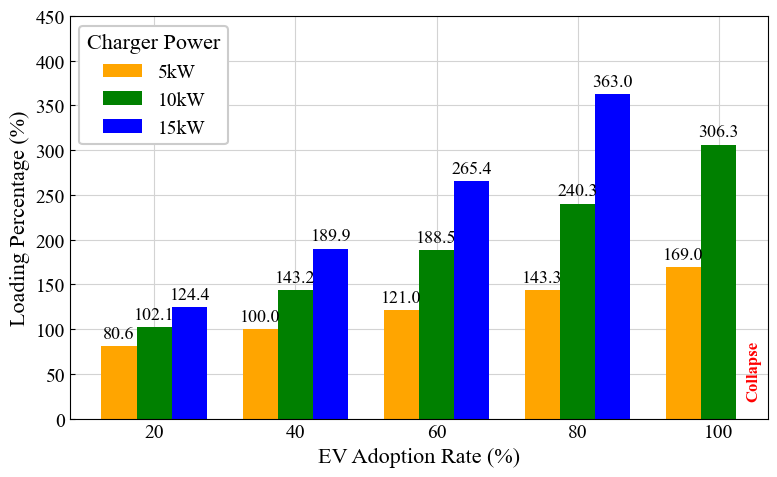

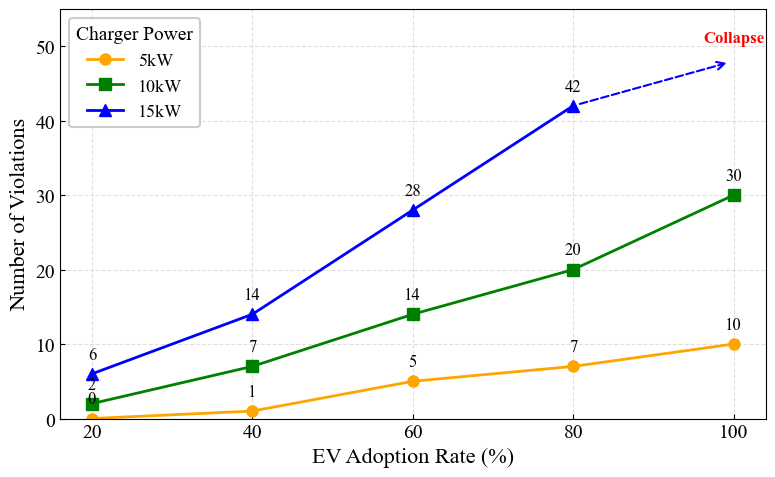

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

colors = {'5kW': 'orange', '10kW': 'green', '15kW': 'blue'}
x_labels = ['20', '40', '60', '80', '100']
x = np.arange(len(x_labels))

data_loading = {
    '5kW':  [80.6, 100.0, 121.0, 143.3, 169.0],
    '10kW': [102.1, 143.2, 188.5, 240.3, 306.3],
    '15kW': [124.4, 189.9, 265.4, 363.0, np.nan] 
}

data_violations = {
    '5kW':  [0, 1, 5, 7, 10],
    '10kW': [2, 7, 14, 20, 30],
    '15kW': [6, 14, 28, 42, np.nan]
}

def plot_bar_chart_collapse():
    fig, ax = plt.subplots(figsize=(8, 5))

    rects1 = ax.bar(x - width, data_loading['5kW'], width, label='5kW', color=colors['5kW'])
    rects2 = ax.bar(x, data_loading['10kW'], width, label='10kW', color=colors['10kW'])
    rects3 = ax.bar(x + width, data_loading['15kW'], width, label='15kW', color=colors['15kW'])

    ax.set_ylabel('Loading Percentage (%)')
    ax.set_xlabel('EV Adoption Rate (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 450) 

    ax.grid(True, axis='both', linestyle='-', alpha=1.0, color='#d3d3d3', zorder=0)
    ax.set_axisbelow(True)

    def autolabel_with_collapse(rects, label_key):
        original_data = data_loading[label_key]
        
        for i, rect in enumerate(rects):
            height = rect.get_height()

            if not np.isnan(height):
                ax.annotate(f'{height}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=13)

            else:
                ax.text(rect.get_x() + rect.get_width() / 2, 20, 
                        'Collapse', 
                        ha='center', va='bottom', fontsize=12, 
                        color='red', rotation=90, fontweight='bold')

    autolabel_with_collapse(rects1, '5kW')
    autolabel_with_collapse(rects2, '10kW')
    autolabel_with_collapse(rects3, '15kW')

    ax.legend(title='Charger Power', 
              loc='upper left', 
              framealpha=1, 
              edgecolor='#ccc',
              fontsize=14,         
              title_fontsize=16)
    
    plt.tight_layout()
    plt.savefig('Bar_6.9kV_Collapse.png', dpi=600)
    plt.show()

def plot_line_chart_collapse():
    fig, ax = plt.subplots(figsize=(8, 5))

    markers = {'5kW': 'o', '10kW': 's', '15kW': '^'}

    y_limit = 55 
    ax.set_ylim(0, y_limit)

    for label, values in data_violations.items():
        y_data = np.array(values, dtype=float)

        mask = ~np.isnan(y_data)
        ax.plot(x[mask], y_data[mask], label=label, color=colors[label], 
                marker=markers[label], markersize=8, linestyle='-', linewidth=2)
  
        for i, val in enumerate(y_data):

            if not np.isnan(val):
                ax.annotate(f'{int(val)}', 
                            xy=(x[i], val), 
                            xytext=(0, 8), textcoords='offset points',
                            ha='center', va='bottom', fontsize=12)

            else:
                if i > 0 and not np.isnan(y_data[i-1]):
                    prev_x = x[i-1]
                    prev_y = y_data[i-1]
                    curr_x = x[i]
                    target_y = 48  

                    ax.annotate('', 
                                xy=(curr_x, target_y), 
                                xytext=(prev_x, prev_y),
                                arrowprops=dict(arrowstyle="->", color=colors[label], 
                                                linestyle='--', linewidth=1.5, shrinkA=5, shrinkB=5))

                    ax.text(curr_x, target_y + 2, 'Collapse', 
                            ha='center', va='bottom', 
                            color='red', fontsize=12, fontweight='bold', rotation=0)

    ax.set_ylabel('Number of Violations')
    ax.set_xlabel('EV Adoption Rate (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)

    ax.grid(True, axis='both', linestyle='--', alpha=0.7, color='#d3d3d3')

    ax.legend(title='Charger Power', 
              loc='upper left', 
              framealpha=1, 
              edgecolor='#ccc',
              fontsize=13, 
              title_fontsize=14)
              
    plt.tight_layout()
    plt.savefig('Line_6.9kV_Collapse_Fixed.png', dpi=600)
    plt.show()

plot_bar_chart_collapse()
plot_line_chart_collapse()

In [ ]:
# 2_5 & 15 distribution plot

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import numpy as np
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 14              
rcParams['axes.labelsize'] = 18         
rcParams['xtick.labelsize'] = 16       
rcParams['ytick.labelsize'] = 16        
rcParams['axes.titlesize'] = 18        
rcParams['legend.fontsize'] = 16        
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['axes.grid'] = False 

power_palette = {'5kW': '#FFA000', '10kW': '#2E7D32', '15kW': '#1565C0'}

def add_vertical_separators(ax, num_categories):
    for i in range(num_categories - 1):
        ax.axvline(i + 0.5, color='gray', linestyle='-', linewidth=0.5, alpha=0.3, zorder=0)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)

def plot_voltage_level_final(voltage_level, figure_label):
    if 'df_final_voltage' not in globals(): 
        print("No data loading")
        return

    print(f" {voltage_level} ...")

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    hue_order = ['5kW', '10kW', '15kW']

    ax_therm = axes[0]
    subset_therm = df_final_thermal[df_final_thermal['System Voltage'] == voltage_level]
    
    if not subset_therm.empty:
        sns.stripplot(x='EV Rate (%)', y='Loading (%)', data=subset_therm,
                      hue='Charger Power', hue_order=hue_order, palette=power_palette,
                      jitter=0.25, dodge=True,
                      size=6, alpha=0.6, linewidth=0.1, edgecolor='white',
                      ax=ax_therm, zorder=3)

        ax_therm.axhline(100, color='#D32F2F', linestyle='--', linewidth=2.0, zorder=2) 
        num_cats = len(subset_therm['EV Rate (%)'].unique())
        add_vertical_separators(ax_therm, num_cats)
        
        ax_therm.set_xlim(-0.5, num_cats - 0.5)

        max_load = subset_therm['Loading (%)'].max()
        if pd.isna(max_load) or max_load < 105:
            ax_therm.set_ylim(0, 115)
        else:
            ax_therm.set_ylim(0, max_load * 1.1)
        
        if ax_therm.get_legend(): ax_therm.get_legend().remove()

    ax_therm.set_ylabel('Line Loading (%)')
    plt.setp(ax_therm.get_xticklabels(), visible=False)

    ax_volt = axes[1]
    subset_volt = df_final_voltage[df_final_voltage['System Voltage'] == voltage_level]
    
    if not subset_volt.empty:
        sns.stripplot(x='EV Rate (%)', y='Voltage (p.u.)', data=subset_volt,
                      hue='Charger Power', hue_order=hue_order, palette=power_palette,
                      jitter=0.25, dodge=True,
                      size=6, alpha=0.7, linewidth=0.1, edgecolor='white',
                      ax=ax_volt, zorder=3)

        ax_volt.axhline(0.9, color='#D32F2F', linestyle='--', linewidth=2.0, zorder=2)
        
        num_cats = len(subset_volt['EV Rate (%)'].unique())
        add_vertical_separators(ax_volt, num_cats)

        ax_volt.set_xlim(-0.5, num_cats - 0.5)

        handles, labels = ax_volt.get_legend_handles_labels()
        ax_volt.legend(handles, labels, loc='lower left', ncol=3, title=None, 
                       frameon=True, framealpha=0.95, 
                       fontsize=16, 
                       handletextpad=0.2, columnspacing=1.0)

    ax_volt.set_ylabel('Bus Voltage (p.u.)')
    ax_volt.set_ylim(0.68, 1.05) 
    axes[-1].set_xlabel('EV Adoption Rate (%)')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05, top=0.96) 

    title_text = f"({figure_label}) Loading percentage and bus voltage distribution at {voltage_level} system"
    fig.text(0.5, 0.98, title_text, ha='center', fontsize=18, fontweight='bold')
    
    safe_name = voltage_level.replace(' ', '_')
    #plt.savefig(f'Final_Figure_{figure_label}_{safe_name}.png', dpi=1200, bbox_inches='tight')
    plt.show()

tasks = [
    ('4.16 kV', 'a'),
    ('6.9 kV',  'b'),
    ('13.8 kV', 'c')
]

for volt, label in tasks:
    plot_voltage_level_final(volt, label)

In [27]:
#two cols

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

rcParams['font.size'] = 24              
rcParams['axes.labelsize'] = 28         
rcParams['xtick.labelsize'] = 26        
rcParams['ytick.labelsize'] = 26
rcParams['legend.fontsize'] = 24        
rcParams['axes.titlesize'] = 28         

rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['axes.grid'] = False 
rcParams['lines.linewidth'] = 3.0       
rcParams['patch.linewidth'] = 1.5       

power_palette = {'5kW': '#FFA000', '10kW': '#2E7D32', '15kW': '#1565C0'}

def add_vertical_separators(ax, num_categories):
    for i in range(num_categories - 1):
        ax.axvline(i + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=0)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)

def plot_voltage_level_final(voltage_level, figure_label):
    if 'df_final_voltage' not in globals(): 
        print("//")
        return

    print(f" {voltage_level} ...")
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    hue_order = ['5kW', '10kW', '15kW']

    ax_therm = axes[0]
    subset_therm = df_final_thermal[df_final_thermal['System Voltage'] == voltage_level]
    
    if not subset_therm.empty:
        sns.stripplot(x='EV Rate (%)', y='Loading (%)', data=subset_therm,
                      hue='Charger Power', hue_order=hue_order, palette=power_palette,
                      jitter=0.25, dodge=True,
                      size=10, alpha=0.6, linewidth=0.5, edgecolor='white',
                      ax=ax_therm, zorder=3)
        
        ax_therm.axhline(100, color='#D32F2F', linestyle='--', linewidth=3.5, zorder=2)
        
        num_cats = len(subset_therm['EV Rate (%)'].unique())
        add_vertical_separators(ax_therm, num_cats)
        
        ax_therm.set_xlim(-0.5, num_cats - 0.5)

        max_load = subset_therm['Loading (%)'].max()
        if pd.isna(max_load) or max_load < 105:
            ax_therm.set_ylim(0, 115)
        else:
            ax_therm.set_ylim(0, max_load * 1.1)
        
        if ax_therm.get_legend(): ax_therm.get_legend().remove()

    ax_therm.set_ylabel('Line Loading (%)')
    plt.setp(ax_therm.get_xticklabels(), visible=False)

    ax_therm.yaxis.labelpad = 3

    ax_volt = axes[1]
    subset_volt = df_final_voltage[df_final_voltage['System Voltage'] == voltage_level]
    
    if not subset_volt.empty:
        sns.stripplot(x='EV Rate (%)', y='Voltage (p.u.)', data=subset_volt,
                      hue='Charger Power', hue_order=hue_order, palette=power_palette,
                      jitter=0.25, dodge=True,
                      size=10, alpha=0.7, linewidth=0.5, edgecolor='white',
                      ax=ax_volt, zorder=3)

        ax_volt.axhline(0.9, color='#D32F2F', linestyle='--', linewidth=3.5, zorder=2)
        
        num_cats = len(subset_volt['EV Rate (%)'].unique())
        add_vertical_separators(ax_volt, num_cats)

        ax_volt.set_xlim(-0.5, num_cats - 0.5)

        handles, labels = ax_volt.get_legend_handles_labels()
        ax_volt.legend(handles, labels, loc='lower left', ncol=3, 
                       frameon=True, framealpha=0.95, 
                       fontsize=22, 
                       handletextpad=0.2, columnspacing=1.0)

    ax_volt.set_ylabel('Bus Voltage (p.u.)')
    ax_volt.set_ylim(0.65, 1.05) 
    ax_volt.yaxis.labelpad = 10
    axes[-1].set_xlabel('EV Adoption Rate (%)', labelpad=10)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.06, top=0.90) 

    title_text = f"({figure_label}) Loading percentage and bus voltage distribution at {voltage_level} system"
    fig.text(0.5, 0.94, title_text, ha='center', fontsize=26, fontweight='bold')
    
    safe_name = voltage_level.replace(' ', '_')
    #plt.savefig(f'Final_TopTitle_{figure_label}_{safe_name}.png', dpi=1200, bbox_inches='tight')
    plt.show()

tasks = [
    ('4.16 kV', 'a'),
    ('6.9 kV',  'b'),
    ('13.8 kV', 'c')
]

for volt, label in tasks:
    plot_voltage_level_final(volt, label)

数据未加载
数据未加载
数据未加载


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import numpy as np
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
rcParams['grid.linestyle'] = '--'
rcParams['legend.fontsize'] = 10

styles = {
    '5kW':  {'color': '#FFA000', 'marker': 'o', 'ls': '-'},
    '10kW': {'color': '#2E7D32', 'marker': 's', 'ls': '-'},
    '15kW': {'color': '#1565C0', 'marker': '^', 'ls': '-'}
}

def plot_envelope_summary_polished(voltage_level):
    if df_final_voltage.empty and df_final_thermal.empty: return

    print(f" {voltage_level}")

    fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True) 
    # fig.suptitle(f'System Topology: {voltage_level}', fontsize=13, fontweight='bold', y=0.96)

    ax_volt = axes[0]
    subset_volt = df_final_voltage[df_final_voltage['System Voltage'] == voltage_level]
    
    if not subset_volt.empty:
        stats = subset_volt.groupby(['EV Rate (%)', 'Charger Power'])['Voltage (p.u.)'].agg(['min', 'max']).reset_index()
        
        for pwr in ['5kW', '10kW', '15kW']:
            data = stats[stats['Charger Power'] == pwr]
            if data.empty: continue
            style = styles[pwr]

            ax_volt.plot(data['EV Rate (%)'], data['min'], 
                         color=style['color'], marker=style['marker'], linestyle=style['ls'],
                         label=f'{pwr}', markersize=5, linewidth=1.5)
            ax_volt.fill_between(data['EV Rate (%)'], data['min'], data['max'],
                                 color=style['color'], alpha=0.1, edgecolor=None)

        ax_volt.axhline(0.9, color='#D32F2F', linestyle='--', linewidth=1.2)
        #ax_volt.text(102, 0.9, 'Limit (0.9)', color='#D32F2F', fontsize=9, va='center')

        ax_volt.set_ylim(0.68, 1.05)
        ax_volt.set_ylabel('Min. Voltage (p.u.)')
        ax_volt.legend(loc='lower left', ncol=3, frameon=True, fontsize=9, handletextpad=0.4)

    ax_therm = axes[1]
    subset_therm = df_final_thermal[df_final_thermal['System Voltage'] == voltage_level]
    
    if not subset_therm.empty:
        stats = subset_therm.groupby(['EV Rate (%)', 'Charger Power'])['Loading (%)'].agg(['min', 'max']).reset_index()
        
        for pwr in ['5kW', '10kW', '15kW']:
            data = stats[stats['Charger Power'] == pwr]
            if data.empty: continue
            style = styles[pwr]
            
            ax_therm.plot(data['EV Rate (%)'], data['max'], 
                          color=style['color'], marker=style['marker'], linestyle=style['ls'],
                          label=f'{pwr}', markersize=5, linewidth=1.5)
            ax_therm.fill_between(data['EV Rate (%)'], data['min'], data['max'],
                                  color=style['color'], alpha=0.1, edgecolor=None)

        ax_therm.axhline(100, color='#D32F2F', linestyle='--', linewidth=1.2)
        #ax_therm.text(102, 100, 'Limit (100%)', color='#D32F2F', fontsize=9, va='center')

        max_val = subset_therm['Loading (%)'].max()
        if pd.isna(max_val) or max_val < 105:
            ax_therm.set_ylim(0, 115)
        else:
            ax_therm.set_ylim(0, max_val * 1.15)

        ax_therm.set_ylabel('Max. Loading (%)')

    axes[-1].set_xlabel('EV Adoption Rate (%)')
    plt.tight_layout()
    # plt.subplots_adjust(top=0.92) 
    
    safe_name = voltage_level.replace(' ', '_')
    plt.savefig(f'Envelope_Final_{safe_name}.png', dpi=600, bbox_inches='tight')
    plt.show()

voltages_to_plot = ['4.16 kV', '6.9 kV', '13.8 kV']
for volt in voltages_to_plot:
    plot_envelope_summary_polished(volt)

In [ ]:
# 1 Plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# ==============================================================================
# 1. Data Entry
# ==============================================================================
# Note: np.nan represents Infeasible (Collapse/No Solution)

# --- A. Max Loading % Data ---
data_loading = {
    # 4.16 kV
    ('4.16 kV', '5kW'):  [108.43, 152.57, 199.98, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [108.43, 206.21, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [108.43, np.nan, np.nan, np.nan, np.nan, np.nan],
    # 6.9 kV
    ('6.9 kV', '5kW'):   [59.91, 80.58, 100.02, 121.00, 143.33, 169.03],
    ('6.9 kV', '10kW'):  [59.91, 102.12, 143.22, 188.46, 240.30, 306.26],
    ('6.9 kV', '15kW'):  [59.91, 124.43, 189.93, 265.42, 363.02, np.nan],
    # 13.8 kV
    ('13.8 kV', '5kW'):  [29.05, 38.63, 47.43, 56.75, 66.29, 76.93],
    ('13.8 kV', '10kW'): [29.05, 48.35, 66.20, 84.89, 104.41, 126.59],
    ('13.8 kV', '15kW'): [29.05, 58.14, 85.22, 113.59, 143.59, 178.12],
    # 23.9 kV
    ('23.9 kV', '5kW'):  [16.67, 22.11, 27.10, 32.36, 37.71, 43.66],
    ('23.9 kV', '10kW'): [16.67, 27.62, 37.66, 48.10, 58.87, 70.99],
    ('23.9 kV', '15kW'): [16.67, 33.13, 48.26, 63.93, 80.21, 98.62],
    # 34.5 kV
    ('34.5 kV', '5kW'):  [11.53, 15.29, 18.72, 22.34, 26.03, 30.11],
    ('34.5 kV', '10kW'): [11.53, 19.08, 25.99, 33.16, 40.55, 48.83],
    ('34.5 kV', '15kW'): [11.53, 22.88, 33.27, 44.01, 55.12, 67.64],
}

# --- B. Line Violations Count Data ---
data_line_viol = {
    # 4.16 kV
    ('4.16 kV', '5kW'):  [4, 7, 14, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [4, 16, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [4, np.nan, np.nan, np.nan, np.nan, np.nan],
    # 6.9 kV
    ('6.9 kV', '5kW'):   [0, 0, 1, 5, 7, 10],
    ('6.9 kV', '10kW'):  [0, 2, 7, 14, 20, 30],
    ('6.9 kV', '15kW'):  [0, 6, 14, 28, 42, np.nan],
    # 13.8 kV
    ('13.8 kV', '5kW'):  [0, 0, 0, 0, 0, 0],
    ('13.8 kV', '10kW'): [0, 0, 0, 0, 3, 6],
    ('13.8 kV', '15kW'): [0, 0, 0, 4, 7, 12],
}

# --- C. Voltage Violations Count Data ---
data_voltage_viol = {
    # 4.16 kV
    ('4.16 kV', '5kW'):  [95, 158, 158, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [95, 158, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [95, np.nan, np.nan, np.nan, np.nan, np.nan],
    # 6.9 kV
    ('6.9 kV', '5kW'):   [0, 0, 6, 97, 148, 83], 
    ('6.9 kV', '10kW'):  [0, 0, 6, 97, 148, 158],
    ('6.9 kV', '15kW'):  [0, 0, 97, 158, 175, np.nan],
}

# --- D. Minimum Voltage (p.u.) Data [NEW] ---
# Source: Table IV (10kW) from provided images. 
# Note: For 5kW and 15kW, specific Min Voltage tables were not provided, so they are kept as NaN placeholders.
data_min_voltage = {
    # 4.16 kV
    ('4.16 kV', '5kW'):  [np.nan] * 6, # Placeholder
    ('4.16 kV', '10kW'): [0.87, 0.73, np.nan, np.nan, np.nan, np.nan], # Source: Table IV
    ('4.16 kV', '15kW'): [np.nan] * 6, # Placeholder
    # 6.9 kV
    ('6.9 kV', '5kW'):   [np.nan] * 6, # Placeholder
    ('6.9 kV', '10kW'):  [0.97, 0.93, 0.90, 0.86, 0.82, 0.76], # Source: Table IV
    ('6.9 kV', '15kW'):  [np.nan] * 6, # Placeholder
}

# Helper function: Build DataFrame
def build_df(data_dict, value_name):
    rows = []
    ev_rates = [0, 20, 40, 60, 80, 100]
    for (voltage, power), values in data_dict.items():
        for i, val in enumerate(values):
            rows.append({
                'Voltage': voltage,
                'Power': power,
                'EV Rate': ev_rates[i],
                value_name: val
            })
    return pd.DataFrame(rows)

df_load = build_df(data_loading, 'Max Loading %')
df_line_viol = build_df(data_line_viol, 'Count')
df_volt_count = build_df(data_voltage_viol, 'Count')
df_min_volt = build_df(data_min_voltage, 'Min Voltage (p.u.)')

# ==============================================================================
# 2. Plotting Logic
# ==============================================================================
# Style definitions
styles = {
    '5kW':  {'color': '#ff7f0e', 'marker': 'o', 'linestyle': '-'},   # Orange
    '10kW': {'color': '#2ca02c', 'marker': 's', 'linestyle': '--'},  # Green
    '15kW': {'color': '#1f77b4', 'marker': '^', 'linestyle': ':'},   # Blue
}

def plot_multi_voltage(df, y_col, voltage_levels, title_prefix, ylabel, invert_yaxis=False):
    # Determine subplot layout
    n_cols = 3
    n_rows = (len(voltage_levels) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
    if n_rows * n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i, voltage in enumerate(voltage_levels):
        ax = axes[i]
        subset = df[df['Voltage'] == voltage]
        
        # Plot lines for each Power
        for power in ['5kW', '10kW', '15kW']:
            power_data = subset[subset['Power'] == power]
            style = styles[power]
            
            # Skip if all data is NaN
            if power_data[y_col].isna().all():
                continue
                
            ax.plot(power_data['EV Rate'], power_data[y_col], 
                    label=power, **style, linewidth=2, markersize=8, alpha=0.9)
            
            # Intelligent Infeasible Annotation
            valid_data = power_data.dropna(subset=[y_col])
            if not valid_data.empty:
                last_idx = valid_data.index[-1]
                last_rate = valid_data.loc[last_idx, 'EV Rate']
                last_val = valid_data.loc[last_idx, y_col]
                
                # If last valid point is < 100%, it implies collapse
                if last_rate < 100:
                    offset_y = 0
                    if power == '5kW': offset_y = 5
                    elif power == '15kW': offset_y = -5
                    
                    # Adjust offset for small values (like Voltage p.u.)
                    if last_val < 5: offset_y *= 0.01
                    
                    ax.annotate('Inf.', xy=(last_rate, last_val), 
                                xytext=(last_rate + 5, last_val + offset_y),
                                color=style['color'], fontweight='bold', fontsize=10,
                                arrowprops=dict(arrowstyle="->", color=style['color'], lw=1))

        ax.set_title(f'{voltage}', fontweight='bold', fontsize=12)
        ax.set_xlabel('EV Adoption Rate (%)')
        ax.set_ylabel(ylabel if i % n_cols == 0 else '')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Add a reference line for Voltage (0.9 p.u.)
        if 'Min Voltage' in y_col:
            ax.axhline(0.9, color='red', linestyle='-', linewidth=1, alpha=0.5, label='Limit (0.9)')
        
        # Integer locator for Count
        if 'Count' in y_col:
            from matplotlib.ticker import MaxNLocator
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Hide extra subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Global Legend
    handles, labels = axes[0].get_legend_handles_labels()
    # Deduplicate legend
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. Generate Charts
# ==============================================================================

print("Generating Figure 1: Line Violations Count...")
plot_multi_voltage(
    df_line_viol, 
    'Count', 
    ['4.16 kV', '6.9 kV', '13.8 kV'], 
    'Line Violations', 
    'Count'
)

print("Generating Figure 2: Max Loading %...")
plot_multi_voltage(
    df_load, 
    'Max Loading %', 
    ['4.16 kV', '6.9 kV', '13.8 kV', '23.9 kV', '34.5 kV'], 
    'Max Loading', 
    'Max Loading (%)'
)

print("Generating Figure 3: Voltage Violations Count...")
plot_multi_voltage(
    df_volt_count, 
    'Count', 
    ['4.16 kV', '6.9 kV'], # 13.8kV has 0 voltage violations, so omitted
    'Voltage Violations', 
    'Count'
)

print("Generating Figure 4: Minimum Voltage (Values)...")
plot_multi_voltage(
    df_min_volt, 
    'Min Voltage (p.u.)', 
    ['4.16 kV', '6.9 kV'], 
    'Min Voltage', 
    'Voltage (p.u.)'
)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import rcParams
import matplotlib.patheffects as path_effects 

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 11
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 9
rcParams['axes.linewidth'] = 1.0
rcParams['lines.linewidth'] = 1.5
rcParams['lines.markersize'] = 6


# --- A. Max Loading % ---
data_loading = {
    ('4.16 kV', '5kW'):  [108.4, 152.6, 200.0, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [108.4, 206.2, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [108.4, np.nan, np.nan, np.nan, np.nan, np.nan],
    ('6.9 kV', '5kW'):   [59.9, 80.6, 100.0, 121.0, 143.3, 169.0],
    ('6.9 kV', '10kW'):  [59.9, 102.1, 143.2, 188.5, 240.3, 306.3],
    ('6.9 kV', '15kW'):  [59.9, 124.4, 189.9, 265.4, 363.0, np.nan],
    ('13.8 kV', '5kW'):  [29.1, 38.6, 47.4, 56.8, 66.3, 76.9],
    ('13.8 kV', '10kW'): [29.1, 48.4, 66.2, 84.9, 104.4, 126.6],
    ('13.8 kV', '15kW'): [29.1, 58.1, 85.2, 113.6, 143.6, 178.1],
}

# --- B. Line Violations Count ---
data_line_viol = {
    ('4.16 kV', '5kW'):  [4, 7, 14, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [4, 16, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [4, np.nan, np.nan, np.nan, np.nan, np.nan],
    ('6.9 kV', '5kW'):   [0, 0, 1, 5, 7, 10],
    ('6.9 kV', '10kW'):  [0, 2, 7, 14, 20, 30],
    ('6.9 kV', '15kW'):  [0, 6, 14, 28, 42, np.nan],
    ('13.8 kV', '5kW'):  [0, 0, 0, 0, 0, 0],
    ('13.8 kV', '10kW'): [0, 0, 0, 0, 3, 6],
    ('13.8 kV', '15kW'): [0, 0, 0, 4, 7, 12],
}

# --- C. Min Voltage p.u. ---
data_min_volt = {
    ('4.16 kV', '5kW'):  [0.87, 0.81, 0.74, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [0.87, 0.73, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [0.87, np.nan, np.nan, np.nan, np.nan, np.nan],
    ('6.9 kV', '5kW'):   [0.97, 0.95, 0.94, 0.92, 0.90, 0.88],
    ('6.9 kV', '10kW'):  [0.97, 0.93, 0.90, 0.86, 0.82, 0.76],
    ('6.9 kV', '15kW'):  [0.97, 0.91, 0.86, 0.80, 0.71, np.nan],
}

# --- D. Voltage Violations Count ---
data_volt_viol_count = {
    ('4.16 kV', '5kW'):  [95, 158, 158, np.nan, np.nan, np.nan],
    ('4.16 kV', '10kW'): [95, 158, np.nan, np.nan, np.nan, np.nan],
    ('4.16 kV', '15kW'): [95, np.nan, np.nan, np.nan, np.nan, np.nan],
    ('6.9 kV', '5kW'):   [0, 0, 6, 97, 148, 83],
    ('6.9 kV', '10kW'):  [0, 0, 6, 97, 148, 158],
    ('6.9 kV', '15kW'):  [0, 0, 97, 158, 175, np.nan],
}

def build_df(data_dict, val_name):
    rows = []
    rates = [0, 20, 40, 60, 80, 100]
    for (volt, pwr), vals in data_dict.items():
        for i, v in enumerate(vals):
            rows.append({'Voltage': volt, 'Power': pwr, 'Rate': rates[i], val_name: v})
    return pd.DataFrame(rows)

df_load = build_df(data_loading, 'Loading')
df_lviol = build_df(data_line_viol, 'LineViol')
df_volt = build_df(data_min_volt, 'MinVolt')
df_vviol = build_df(data_volt_viol_count, 'VoltViol')

df_all = df_load.merge(df_lviol, on=['Voltage', 'Power', 'Rate'], how='outer') \
                .merge(df_volt, on=['Voltage', 'Power', 'Rate'], how='outer') \
                .merge(df_vviol, on=['Voltage', 'Power', 'Rate'], how='outer')

styles = {
    '5kW':  {'color': '#FFA500', 'marker': 'o', 'linestyle': '-', 'label': '5kW'},  # Orange
    '10kW': {'color': '#008000', 'marker': 's', 'linestyle': '-', 'label': '10kW'},  # Green
    '15kW': {'color': '#0000FF', 'marker': '^', 'linestyle': '-', 'label': '15kW'},  # Blue
}

bar_width = 6
offsets = {'5kW': -bar_width, '10kW': 0, '15kW': bar_width}

def apply_text_outline(text_obj):
    text_obj.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='white'),
        path_effects.Normal()
    ])

def add_bar_labels(ax, rects):
    for rect in rects:
        height = rect.get_height()
        if pd.isna(height): continue
        txt = ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color='black', zorder=20)
        apply_text_outline(txt)

def add_line_labels(ax, x_vals, y_vals, color):
    for x, y in zip(x_vals, y_vals):
        if pd.isna(y): continue
        txt = ax.annotate(f'{y:.2f}' if y < 1 else f'{y:.0f}',
                    xy=(x, y),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, color='black', weight='normal', zorder=20)
        apply_text_outline(txt)


def plot_single_voltage(voltage_level, chart_type):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax2 = ax1.twinx()

    subset = df_all[df_all['Voltage'] == voltage_level].copy()

    if voltage_level == '4.16 kV':
        subset = subset[subset['Rate'] <= 40]
        x_ticks = [0, 20, 40]
    else:
        x_ticks = [0, 20, 40, 60, 80, 100]

    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.0)

    ax1.grid(True, axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.5, zorder=0)
    ax1.set_axisbelow(True) 

    powers = ['5kW', '10kW', '15kW']

    if chart_type == 'thermal':
        primary_col = 'Loading'      # Bar
        secondary_col = 'LineViol'   # Line
        y1_label = 'Max Loading (%)'
        y2_label = 'Violations (#)'

        for pwr in powers:
            data = subset[subset['Power'] == pwr]
            if data.empty: continue

            rects = ax1.bar(data['Rate'] + offsets[pwr], data[primary_col],
                            width=bar_width, label=f'{pwr}',
                            color=styles[pwr]['color'], edgecolor='none', zorder=2)
            add_bar_labels(ax1, rects)

        for pwr in powers:
            data = subset[subset['Power'] == pwr]
            if data.empty: continue

            ax2.plot(data['Rate'], data[secondary_col],
                     marker=styles[pwr]['marker'], color=styles[pwr]['color'],
                     linestyle=styles[pwr]['linestyle'], zorder=10) # Line zorder highest

        ymax_load = subset[primary_col].max()
        ax1.set_ylim(0, ymax_load * 1.35)
        ymax_viol = subset[secondary_col].max()
        ax2.set_ylim(0, max(ymax_viol * 1.35, 5))

    elif chart_type == 'voltage':
        primary_col = 'MinVolt'     # Line (Left)
        secondary_col = 'VoltViol'  # Bar (Right)
        y1_label = 'Min Voltage (p.u.)'
        y2_label = 'Violations (#)'

        for pwr in powers:
            data = subset[subset['Power'] == pwr]
            if data.empty: continue

            # Line
            ax1.plot(data['Rate'], data[primary_col],
                     marker=styles[pwr]['marker'], color=styles[pwr]['color'],
                     linestyle=styles[pwr]['linestyle'], zorder=10)

            # Line Labels
            add_line_labels(ax1, data['Rate'], data[primary_col], styles[pwr]['color'])

        for pwr in powers:
            data = subset[subset['Power'] == pwr]
            if data.empty: continue

            rects = ax2.bar(data['Rate'] + offsets[pwr], data[secondary_col],
                            width=bar_width, label=f'{pwr}',
                            color=styles[pwr]['color'], alpha=0.3, zorder=1)

        # 0.9 p.u. 
        ax1.axhline(0.9, color='red', linestyle=':', linewidth=1.5)
        ax1.set_ylim(0.65, 1.05)
        ymax_viol = subset[secondary_col].max()
        ax2.set_ylim(0, max(ymax_viol * 1.3, 10))

    ax1.set_ylabel(y1_label)
    ax2.set_ylabel(y2_label)
    ax1.set_xlabel('EV Adoption Rate (%)')

    ax1.set_xticks(x_ticks)
    ax1.set_title(f'System Voltage: {voltage_level}', pad=10)

    legend_elements = [
        plt.Line2D([0], [0], color='orange', marker='o', lw=1.5, label='5kW'),
        plt.Line2D([0], [0], color='green', marker='s', lw=1.5, label='10kW'),
        plt.Line2D([0], [0], color='blue', marker='^', lw=1.5, label='15kW')
    ]

    ax1.legend(handles=legend_elements, loc='upper left',
               title='Charger Power', frameon=True, framealpha=0.9,
               fontsize=9, handletextpad=0.5)

    plt.tight_layout()
    plt.show()

print("Generating Figure 1 Components (Thermal)...")
# 1. 4.16 kV (Truncated > 40%)
plot_single_voltage('4.16 kV', 'thermal')
# 2. 6.9 kV
plot_single_voltage('6.9 kV', 'thermal')
# 3. 13.8 kV
plot_single_voltage('13.8 kV', 'thermal')

print("\nGenerating Figure 2 Components (Voltage)...")
# 4. 4.16 kV (Truncated > 40%)
plot_single_voltage('4.16 kV', 'voltage')
# 5. 6.9 kV
plot_single_voltage('6.9 kV', 'voltage')